In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2)

        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 10)

        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x

In [ ]:
model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
#optimizer = optim.SGD(
    #model.parameters(),
    #lr=0.01
#)

In [ ]:
epochs = 5

train_losses = []
train_accs = []

for epoch in range(epochs):

    model.train()
    total_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    accuracy = 100 * correct / total

    train_losses.append(total_loss / len(train_loader))
    train_accs.append(accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {total_loss/len(train_loader):.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.1557 Accuracy: 95.34%
Epoch [2/5] Loss: 0.0824 Accuracy: 97.67%
Epoch [3/5] Loss: 0.0660 Accuracy: 98.16%
Epoch [4/5] Loss: 0.0535 Accuracy: 98.47%
Epoch [5/5] Loss: 0.0456 Accuracy: 98.71%


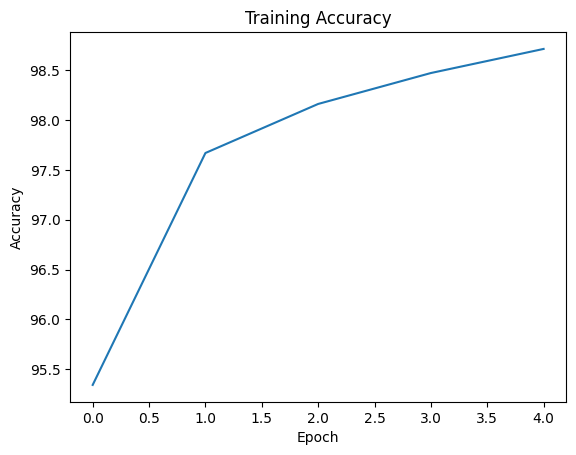

In [ ]:
plt.plot(train_accs)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

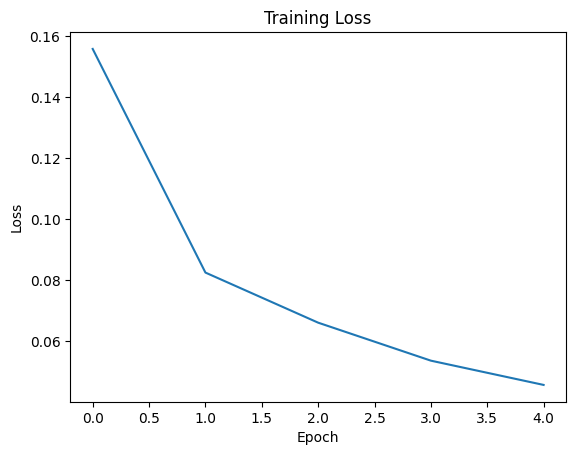

In [ ]:
plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [ ]:
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)